# Brain Tumor MRI Classification — Hybrid Multi-Model Ensemble

**Backbones fused in this project:** Custom CNN &bull; EfficientNetB3 &bull; VGG16 &bull; ResNet50 &bull; DenseNet121 &bull; MedicalNet-inspired residual network

## What this notebook does
This is a full rewrite of the original single-VGG16 prototype into a **hybrid, multi-branch deep learning system** for classifying brain MRI scans into four classes: `glioma`, `meningioma`, `notumor`, `pituitary`.

Instead of relying on one pretrained network, six independent feature-extraction branches look at the **same input image** and their learned representations are **fused** into one classifier head. The idea is that each architecture has different inductive biases (depth, receptive field, connectivity pattern), so combining them can capture complementary patterns in the MRI textures that any single network might miss.

**The six branches:**
1. **Custom CNN** — a small from-scratch convolutional network, trained only on this dataset, with no external bias.
2. **EfficientNetB3** — compound-scaled efficient architecture, ImageNet pretrained.
3. **VGG16** — classic deep CNN with small 3x3 filters, ImageNet pretrained (this was the original project's only model).
4. **ResNet50** — residual connections that ease gradient flow in very deep networks, ImageNet pretrained.
5. **DenseNet121** — densely-connected blocks that encourage feature reuse, ImageNet pretrained.
6. **MedicalNet-inspired branch** — see the note below.

> **Honest note on "MedicalNet":** the real MedicalNet / Med3D project is a set of **3D ResNets pretrained on CT volumes in PyTorch** (designed for volumetric scans, not single 2D JPEG/PNG slices, and not natively loadable inside a Keras/TensorFlow graph). Since this dataset is 2D MRI slices, we cannot legitimately drop in Med3D's actual pretrained 3D weights here without a separate PyTorch pipeline and 3D volume data. To stay technically honest, this notebook instead includes a **2D residual CNN branch inspired by MedicalNet's architecture family** (stacked residual blocks, similar receptive-field growth), trained from scratch alongside the rest of the hybrid model. The final "Optional — True 3D MedicalNet" section at the end explains exactly how to plug in the real PyTorch Med3D weights if you later obtain 3D volumetric data.

## Notebook map
1. Environment setup & imports
2. Configuration
3. Data loading & train/val/test split
4. Exploratory data visualization
5. tf.data input pipeline (shared raw pixels + per-backbone preprocessing)
6. Branch builders (Custom CNN, VGG16, ResNet50, DenseNet121, EfficientNetB3, MedicalNet-inspired)
7. Hybrid fusion model
8. Class weights & callbacks
9. Two-phase training (frozen backbones -> fine-tune)
10. Training curves
11. Evaluation on held-out test set (classification report, confusion matrix, ROC-AUC)
12. Individual backbone baselines (for comparison + reused later as an ensemble)
13. Weighted soft-voting ensemble (Approach B, no giant model needed)
14. Grad-CAM explainability
15. Save / load the hybrid model
16. Single-image inference tool
17. Batch inference demo
18. Appendix: plugging in a true 3D MedicalNet branch

## 1. Environment Setup & Imports

In [1]:
!pip install tensorflow scikit-learn matplotlib seaborn pillow

In [2]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import vgg16, resnet50, densenet, efficientnet

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs detected:", gpus)
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)


TensorFlow version: 2.20.0
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Configuration

In [3]:
# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- Paths (EDIT THESE for your machine / Kaggle / Colab) ----
# Expected layout (same as the original project):
#   train_dir/<class_name>/*.jpg
#   test_dir/<class_name>/*.jpg
train_dir = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training"
test_dir  = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing"

# ---- Image / training config ----
IMAGE_SIZE   = 224          # shared input size for ALL six branches
NUM_CHANNELS = 3
BATCH_SIZE   = 16           # 6 backbones running together is memory-heavy; lower this if you hit OOM
PROJ_DIM     = 256          # dimensionality each branch is projected to before fusion
VAL_SPLIT    = 0.15         # carved out of the training folder (stratified)

# ---- Class names (alphabetical, matches os.listdir order in most Kaggle copies of this dataset) ----
CLASS_NAMES = sorted(os.listdir(train_dir)) if os.path.isdir(train_dir) else \
    ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
print("Classes:", CLASS_NAMES)

# ---- Optional: mixed precision to cut memory use on modern GPUs ----
USE_MIXED_PRECISION = False
if USE_MIXED_PRECISION:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision enabled:", tf.keras.mixed_precision.global_policy())


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 3. Data Loading & Train / Val / Test Split

In [4]:
def collect_paths_labels(root_dir):
    paths, labels = [], []
    for label in os.listdir(root_dir):
        class_dir = os.path.join(root_dir, label)
        if not os.path.isdir(class_dir):
            continue
        for fname in os.listdir(class_dir):
            paths.append(os.path.join(class_dir, fname))
            labels.append(label)
    return paths, labels

all_train_paths, all_train_labels = collect_paths_labels(train_dir)
test_paths, test_labels = collect_paths_labels(test_dir)

# Stratified split of the training folder into train / validation.
# (The original notebook referenced val_paths/val_labels without ever creating
#  them — this fixes that bug properly with a real stratified split.)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_train_paths,
    all_train_labels,
    test_size=VAL_SPLIT,
    stratify=all_train_labels,
    random_state=SEED,
)

print(f"Train images:      {len(train_paths)}")
print(f"Validation images: {len(val_paths)}")
print(f"Test images:       {len(test_paths)}")


Train images:      4760
Validation images: 840
Test images:       1600


## 4. Exploratory Data Visualization

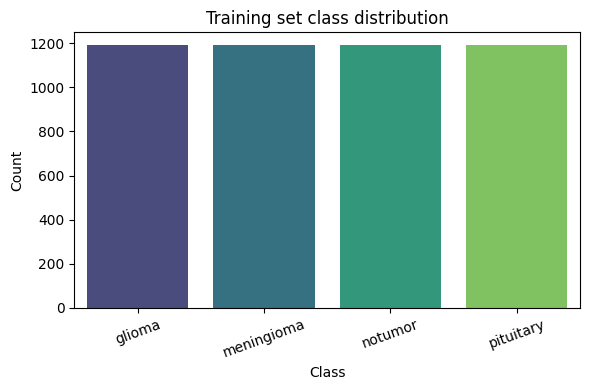

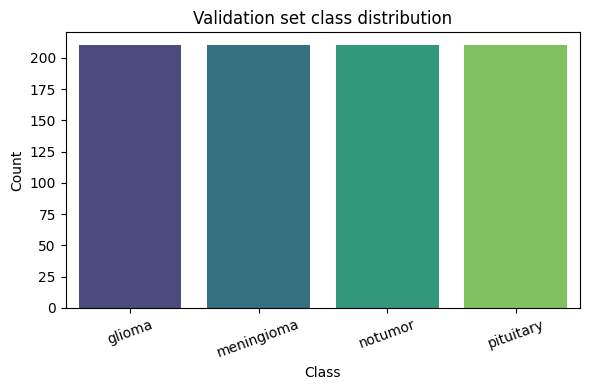

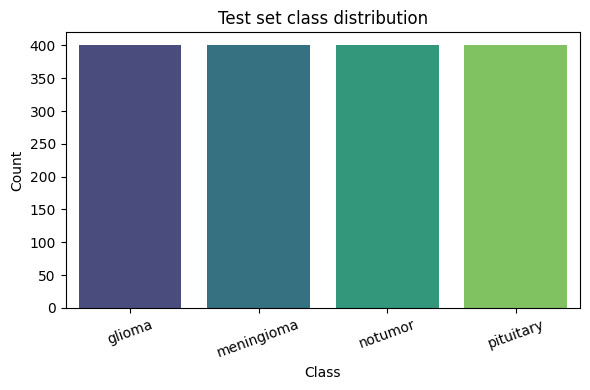

In [5]:
def plot_class_distribution(labels, title):
    values, counts = np.unique(labels, return_counts=True)
    plt.figure(figsize=(6, 4))
    sns.barplot(x=values, y=counts, hue=values, palette='viridis', legend=False)
    plt.title(title)
    plt.ylabel("Count")
    plt.xlabel("Class")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

plot_class_distribution(train_labels, "Training set class distribution")
plot_class_distribution(val_labels,   "Validation set class distribution")
plot_class_distribution(test_labels,  "Test set class distribution")


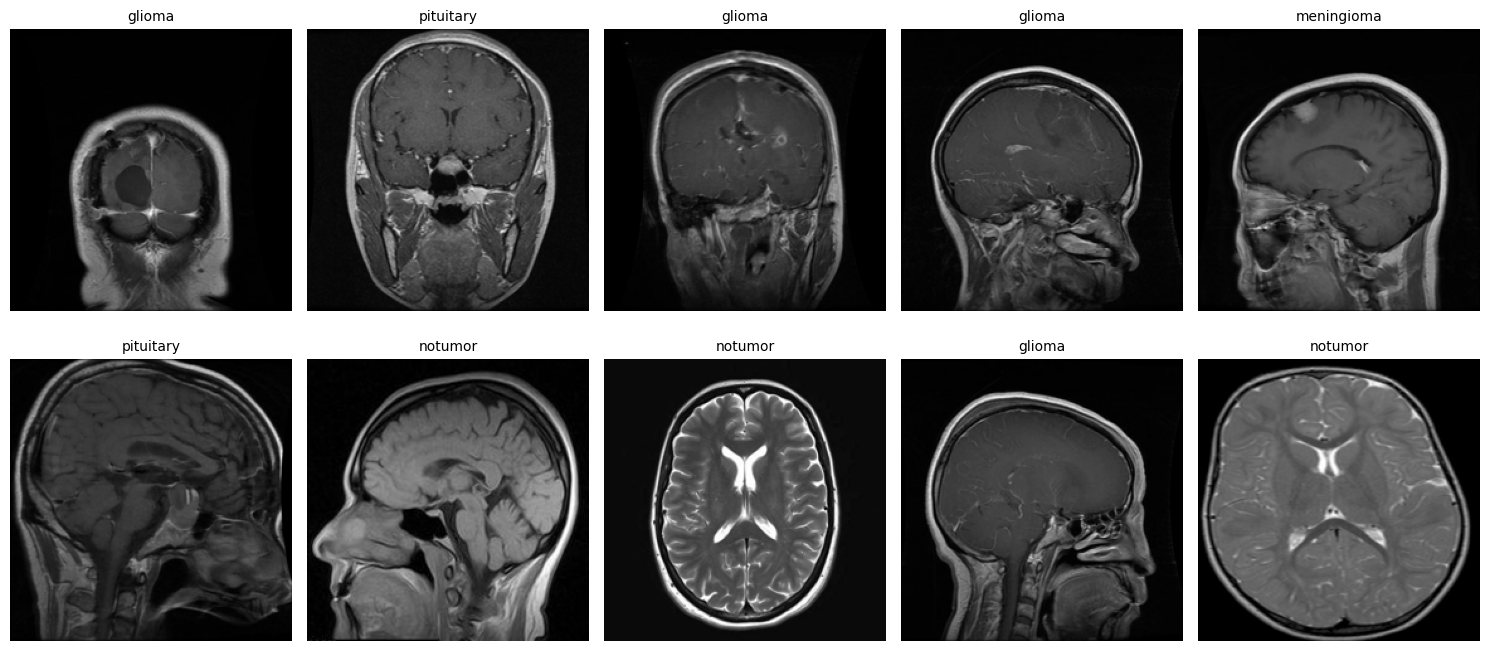

In [6]:
# Sample grid of images
random_indices = random.sample(range(len(train_paths)), 10)
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.ravel()
for i, idx in enumerate(random_indices):
    img = Image.open(train_paths[idx]).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(train_labels[idx], fontsize=10)
plt.tight_layout()
plt.show()


## 5. tf.data Input Pipeline

Every branch shares **one raw image tensor** (pixels in `[0, 255]`, resized to `IMAGE_SIZE`).
Backbone-specific normalization (VGG "caffe" style, ResNet "caffe" style, DenseNet "torch" style,
EfficientNet's built-in rescaling) happens **inside the model itself**, as the first step of each
branch. This keeps one clean input pipeline while still feeding every backbone the exact
preprocessing it was pretrained with.

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.04),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.10),
], name="data_augmentation")

def _load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    image = tf.cast(image, tf.float32)  # kept in [0, 255]; branches handle their own scaling
    return image, label

def make_dataset(paths, labels, training=False, batch_size=BATCH_SIZE):
    label_ids = [CLASS_TO_IDX[l] for l in labels]
    ds = tf.data.Dataset.from_tensor_slices((list(paths), label_ids))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(_load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds   = make_dataset(val_paths,   val_labels,   training=False)
test_ds  = make_dataset(test_paths,  test_labels,  training=False)


I0000 00:00:1790395559.511621      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790395559.515185      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 6. Branch Builders

Each function below returns a **feature tensor projected to `PROJ_DIM` dimensions**, so that all
six branches contribute equally-sized vectors to the fusion layer regardless of their native
feature size (VGG16=512, ResNet50=2048, DenseNet121=1024, EfficientNetB3=1536).

In [8]:
def build_projection_head(x, name, proj_dim=PROJ_DIM, dropout=0.3):
    """Shrinks / standardizes a branch's raw feature vector before fusion."""
    x = layers.Dense(proj_dim, activation='relu', name=f'{name}_proj_dense')(x)
    x = layers.BatchNormalization(name=f'{name}_proj_bn')(x)
    x = layers.Dropout(dropout, name=f'{name}_proj_drop')(x)
    return x


def build_pretrained_branch(name, application_fn, preprocess_fn, input_tensor, proj_dim=PROJ_DIM):
    """Wraps a Keras Applications backbone: preprocess -> ImageNet backbone -> GAP -> projection.
    All backbone layers start frozen; call unfreeze_backbones() later for fine-tuning.
    Returns (projected_feature_tensor, base_model) so it can be fine-tuned afterwards.
    """
    preprocessed = layers.Lambda(preprocess_fn, name=f'{name}_preprocess')(input_tensor)
    base = application_fn(
        include_top=False,
        weights='imagenet',
        input_tensor=preprocessed,
        pooling='avg',
    )
    base._name = f'{name}_backbone'
    for layer in base.layers:
        layer.trainable = False
    feat = build_projection_head(base.output, name, proj_dim)
    return feat, base


def build_custom_cnn_branch(input_tensor, proj_dim=PROJ_DIM):
    """From-scratch CNN — no ImageNet bias, learns purely from MRI textures."""
    x = layers.Rescaling(1. / 255, name='customcnn_rescale')(input_tensor)
    for filters in (32, 64, 128, 256):
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    return build_projection_head(x, 'customcnn', proj_dim)


def _residual_block(x, filters, stride=1, name=''):
    shortcut = x
    y = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False, name=f'{name}_conv1')(x)
    y = layers.BatchNormalization(name=f'{name}_bn1')(y)
    y = layers.ReLU(name=f'{name}_relu1')(y)
    y = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False, name=f'{name}_conv2')(y)
    y = layers.BatchNormalization(name=f'{name}_bn2')(y)
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False, name=f'{name}_proj')(shortcut)
        shortcut = layers.BatchNormalization(name=f'{name}_projbn')(shortcut)
    out = layers.Add(name=f'{name}_add')([y, shortcut])
    out = layers.ReLU(name=f'{name}_out')(out)
    return out


def build_medicalnet_inspired_branch(input_tensor, proj_dim=PROJ_DIM):
    """2D residual network inspired by MedicalNet/Med3D's block design (see markdown note above
    on why we don't load the real 3D pretrained weights for a 2D-slice dataset)."""
    x = layers.Rescaling(1. / 255, name='mednet_rescale')(input_tensor)
    x = layers.Conv2D(32, 7, strides=2, padding='same', use_bias=False, name='mednet_stem_conv')(x)
    x = layers.BatchNormalization(name='mednet_stem_bn')(x)
    x = layers.ReLU(name='mednet_stem_relu')(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same', name='mednet_stem_pool')(x)
    x = _residual_block(x, 32,  stride=1, name='mednet_block1a')
    x = _residual_block(x, 32,  stride=1, name='mednet_block1b')
    x = _residual_block(x, 64,  stride=2, name='mednet_block2a')
    x = _residual_block(x, 64,  stride=1, name='mednet_block2b')
    x = _residual_block(x, 128, stride=2, name='mednet_block3a')
    x = _residual_block(x, 128, stride=1, name='mednet_block3b')
    x = layers.GlobalAveragePooling2D(name='mednet_gap')(x)
    return build_projection_head(x, 'mednet', proj_dim)


## 7. Hybrid Fusion Model

In [11]:
def build_pretrained_branch(
    model_name,
    Backbone,
    preprocess_fn,
    inp,
    proj_dim
):
    # Get image size from main input
    image_size = inp.shape[1]

    # Create a separate input for this backbone
    branch_input = layers.Input(
        shape=(image_size, image_size, 3),
        name=f"{model_name}_input"
    )

    # Preprocessing
    x = layers.Lambda(
        lambda z: preprocess_fn(z),
        name=f"{model_name}_preprocess"
    )(branch_input)

    # Pretrained backbone
    base = Backbone(
        include_top=False,
        weights="imagenet",
        input_shape=(image_size, image_size, 3),
        pooling="avg"
    )

    # Freeze pretrained backbone
    base.trainable = False

    # Extract features
    x = base(x)

    # Projection
    x = layers.Dense(
        proj_dim,
        activation="relu",
        name=f"{model_name}_projection"
    )(x)

    x = layers.BatchNormalization(
        name=f"{model_name}_projection_bn"
    )(x)

    x = layers.Dropout(
        0.20,
        name=f"{model_name}_projection_dropout"
    )(x)

    # Make this branch a separate nested model
    branch_model = models.Model(
        inputs=branch_input,
        outputs=x,
        name=f"{model_name}_branch"
    )

    # Connect the branch model to the main input
    branch_output = branch_model(inp)

    return branch_output, base

# HYBRID MODEL
def build_hybrid_model(
    image_size=IMAGE_SIZE,
    num_classes=NUM_CLASSES,
    proj_dim=PROJ_DIM
):
    inp = layers.Input(
        shape=(image_size, image_size, 3),
        name="input_image"
    )

    backbones = {}

    # Custom branches
    custom_feat = build_custom_cnn_branch(
        inp,
        proj_dim
    )

    mednet_feat = build_medicalnet_inspired_branch(
        inp,
        proj_dim
    )

    # Pretrained branches
    vgg_feat, backbones["vgg16"] = build_pretrained_branch(
        "vgg16",
        vgg16.VGG16,
        vgg16.preprocess_input,
        inp,
        proj_dim
    )

    resnet_feat, backbones["resnet50"] = build_pretrained_branch(
        "resnet50",
        resnet50.ResNet50,
        resnet50.preprocess_input,
        inp,
        proj_dim
    )

    dense_feat, backbones["densenet121"] = build_pretrained_branch(
        "densenet121",
        densenet.DenseNet121,
        densenet.preprocess_input,
        inp,
        proj_dim
    )

    eff_feat, backbones["efficientnetb3"] = build_pretrained_branch(
        "efficientnetb3",
        efficientnet.EfficientNetB3,
        efficientnet.preprocess_input,
        inp,
        proj_dim
    )

    # Feature fusion
    fused = layers.Concatenate(
        name="fusion_concat"
    )([
        custom_feat,
        mednet_feat,
        vgg_feat,
        resnet_feat,
        dense_feat,
        eff_feat
    ])

    # Fusion classifier
    x = layers.Dense(
        512,
        activation="relu",
        name="fusion_dense1"
    )(fused)

    x = layers.BatchNormalization(
        name="fusion_bn1"
    )(x)

    x = layers.Dropout(
        0.4,
        name="fusion_drop1"
    )(x)

    x = layers.Dense(
        256,
        activation="relu",
        name="fusion_dense2"
    )(x)

    x = layers.Dropout(
        0.3,
        name="fusion_drop2"
    )(x)

    out = layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
        name="predictions"
    )(x)

    # Final model
    model = models.Model(
        inputs=inp,
        outputs=out,
        name="Hybrid_MultiModel_BrainTumor"
    )

    return model, backbones

# BUILD MODEL
hybrid_model, backbones = build_hybrid_model()

hybrid_model.summary(show_trainable=True)

print(
    "\nTotal params:",
    f"{hybrid_model.count_params():,}"
)

Model: "Hybrid_MultiModel_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_image       │ (None, 224,     │         0 │ -              │   -   │
│ (InputLayer)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ mednet_rescale    │ (None, 224,     │         0 │ input_image[0… │   -   │
│ (Rescaling)       │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ mednet_stem_conv  │ (None, 112,     │     4,704 │ mednet_rescal… │   Y   │
│ (Conv2D)          │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ mednet_stem_bn    │ (None, 112,     │       128 │ mednet_stem_c… │   Y   │
│ (BatchNormalizat… │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ mednet_stem_relu  │ (None, 112,     │         0 │ mednet_stem_b… │   -   │
│ (ReLU)            │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ mednet_stem_pool  │ (None, 56, 56,  │         0 │ mednet_stem_r… │   -   │
│ (MaxPooling2D)    │ 32)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ mednet_block1a_c… │ (None, 56, 56,  │     9,216 │ mednet_stem_p… │   Y   │
│ (Conv2D)          │ 32)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ mednet_block1a_b… │ (None, 56, 56,  │       128 │ mednet_block1… │   Y   │
│ (BatchNormalizat… │ 32)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ mednet_block1a_r… │ (None, 56, 56,  │         0 │ mednet_block1… │   -   │
│ (ReLU)            │ 32)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ mednet_block1a_c… │ (None, 56, 56,  │     9,216 │ mednet_block1… │   Y   │
│ (Conv2D)          │ 32)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ mednet_block1a_b… │ (None, 56, 56,  │       128 │ mednet_block1… │   Y   │
│ (BatchNormalizat… │ 32)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ mednet_block1a_a… │ (None, 56, 56,  │         0 │ mednet_block1… │   -   │
│ (Add)             │ 32)             │           │ mednet_stem_p… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ mednet_block1a_o… │ (None, 56, 56,  │         0 │ mednet_block1… │   -   │
│ (ReLU)            │ 32)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ mednet_block1b_c… │ (None, 56, 56,  │     9,216 │ mednet_block1… │   Y   │
│ (Conv2D)          │ 32)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ mednet_block1b_b… │ (None, 56, 56,  │       128 │ mednet_block1… │   Y   │
│ (BatchNormalizat… │ 32)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ mednet_block1b_r… │ (None, 56, 56,  │         0 │ mednet_block1… │   -   │
│ (ReLU)            │ 32)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ mednet_block1b_c… │ (None, 56, 56,  │     9,216 │ mednet_block1… │   Y 

 Total params: 59,553,235 (227.18 MB)

 Trainable params: 3,422,500 (13.06 MB)

 Non-trainable params: 56,130,735 (214.12 MB)


Total params: 59,553,235


In [13]:
def unfreeze_backbones(backbones, n_layers=10):
    """Unfreezes the last n_layers of every pretrained backbone (BatchNorm layers stay frozen
    so their running statistics aren't disturbed by small fine-tuning batches)."""
    for name, base in backbones.items():
        count = 0
        for layer in base.layers[-n_layers:]:
            if not isinstance(layer, layers.BatchNormalization):
                layer.trainable = True
                count += 1
        print(f"{name}: unfroze {count} layers")


## 8. Class Weights & Callbacks

In [14]:
train_label_ids = np.array([CLASS_TO_IDX[l] for l in train_labels])
class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_label_ids,
)
class_weights = dict(enumerate(class_weight_values))
print("Class weights:", {CLASS_NAMES[i]: round(w, 3) for i, w in class_weights.items()})

def make_callbacks(checkpoint_path):
    return [
        callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
        callbacks.ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True),
    ]


Class weights: {'glioma': np.float64(1.0), 'meningioma': np.float64(1.0), 'notumor': np.float64(1.0), 'pituitary': np.float64(1.0)}


## 9. Two-Phase Training

**Phase 1 — Warm-up:** all five ImageNet backbones stay fully frozen. Only the from-scratch
branches (Custom CNN, MedicalNet-inspired) and the fusion head learn, so the randomly-initialized
layers don't send noisy gradients backward into the pretrained weights.

**Phase 2 — Fine-tuning:** the last few layers of each pretrained backbone are unfrozen and the
whole model is trained further at a much lower learning rate.

In [15]:
PHASE1_EPOCHS = 20
PHASE2_EPOCHS = 30

hybrid_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history1 = hybrid_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks('best_hybrid_phase1.keras'),
)


Epoch 1/20


2026-09-26 04:15:23.754466: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 04:15:23.898005: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 04:15:24.239816: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 04:15:24.387025: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 04:15:25.166373: E external/local_xla/xla/stream_

297/298 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.6042 - loss: 1.0690

2026-09-26 04:18:00.445807: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 04:18:00.584231: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 04:18:00.912518: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 04:18:01.059315: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 04:18:01.865187: E external/local_xla/xla/stream_

298/298 ━━━━━━━━━━━━━━━━━━━━ 335s 745ms/step - accuracy: 0.7185 - loss: 0.7707 - val_accuracy: 0.7571 - val_loss: 0.6068 - learning_rate: 1.0000e-04
Epoch 2/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 110s 367ms/step - accuracy: 0.8313 - loss: 0.4653 - val_accuracy: 0.8274 - val_loss: 0.4906 - learning_rate: 1.0000e-04
Epoch 3/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 110s 368ms/step - accuracy: 0.8704 - loss: 0.3574 - val_accuracy: 0.8845 - val_loss: 0.3248 - learning_rate: 1.0000e-04
Epoch 4/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 109s 366ms/step - accuracy: 0.8800 - loss: 0.3275 - val_accuracy: 0.9071 - val_loss: 0.2684 - learning_rate: 1.0000e-04
Epoch 5/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 105s 352ms/step - accuracy: 0.8954 - loss: 0.2845 - val_accuracy: 0.8905 - val_loss: 0.2941 - learning_rate: 1.0000e-04
Epoch 6/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 109s 366ms/step - accuracy: 0.9101 - loss: 0.2536 - val_accuracy: 0.9095 - val_loss: 0.2815 - learning_rate: 1.0000e-04
Epoch 7/20
298/298 ━━━━━━━━━━━━━━━━━━━━ 105s 351ms/

In [16]:
unfreeze_backbones(backbones, n_layers=10)

hybrid_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),  # much lower LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history2 = hybrid_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS + PHASE2_EPOCHS,
    initial_epoch=history1.epoch[-1] + 1,
    class_weight=class_weights,
    callbacks=make_callbacks('best_hybrid_phase2.keras'),
)


vgg16: unfroze 10 layers
resnet50: unfroze 7 layers
densenet121: unfroze 7 layers
efficientnetb3: unfroze 8 layers
Epoch 21/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 365s 821ms/step - accuracy: 0.9580 - loss: 0.1132 - val_accuracy: 0.9405 - val_loss: 0.1439 - learning_rate: 1.0000e-05
Epoch 22/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 130s 436ms/step - accuracy: 0.9546 - loss: 0.1278 - val_accuracy: 0.9357 - val_loss: 0.2086 - learning_rate: 1.0000e-05
Epoch 23/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 130s 435ms/step - accuracy: 0.9536 - loss: 0.1295 - val_accuracy: 0.9345 - val_loss: 0.1872 - learning_rate: 1.0000e-05
Epoch 24/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 129s 433ms/step - accuracy: 0.9534 - loss: 0.1378 - val_accuracy: 0.9274 - val_loss: 0.2556 - learning_rate: 1.0000e-05
Epoch 25/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 135s 453ms/step - accuracy: 0.9630 - loss: 0.1075 - val_accuracy: 0.9440 - val_loss: 0.1742 - learning_rate: 5.0000e-06
Epoch 26/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 135s 453ms/step - accuracy: 0.9637 - lo

## 10. Training Curves

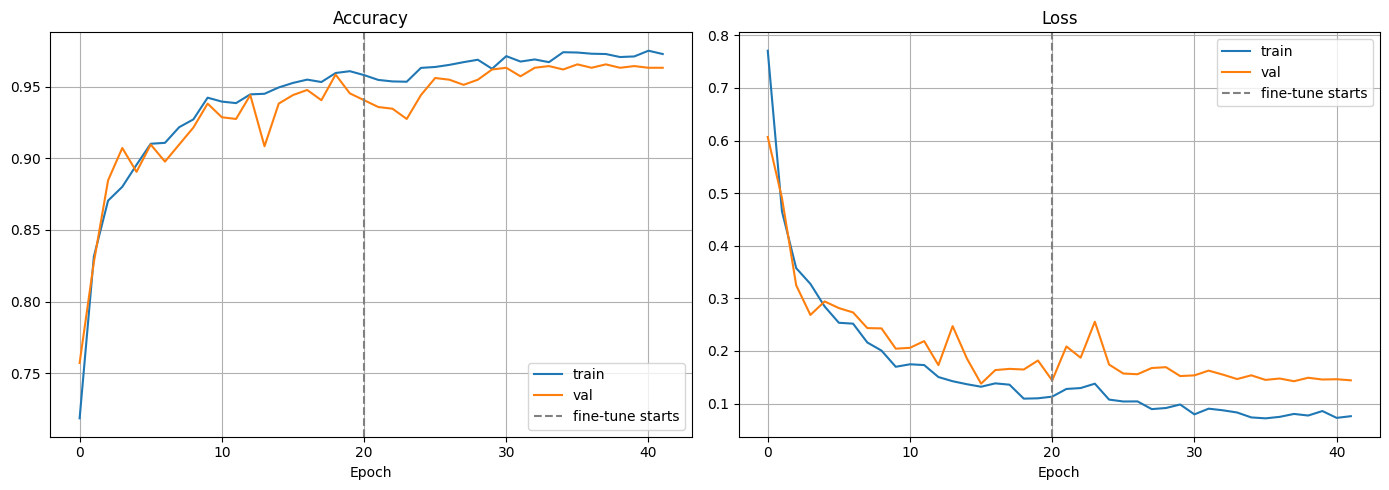

In [21]:
def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history.get(key, [])
    return combined

history = combine_histories(history1, history2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['accuracy'], label='train')
axes[0].plot(history['val_accuracy'], label='val')
axes[0].axvline(
    PHASE1_EPOCHS,
    color='gray',
    linestyle='--',
    label='fine-tune starts'
)
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['loss'], label='train')
axes[1].plot(history['val_loss'], label='val')
axes[1].axvline(
    PHASE1_EPOCHS,
    color='gray',
    linestyle='--',
    label='fine-tune starts'
)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 11. Evaluation on the Held-Out Test Set

In [22]:
test_label_ids = np.array([CLASS_TO_IDX[l] for l in test_labels])

test_probs = hybrid_model.predict(
    test_ds,
    verbose=1
)

test_pred_ids = np.argmax(test_probs, axis=1)

print("HYBRID MODEL — CLASSIFICATION REPORT")

print(
    classification_report(
        test_label_ids,
        test_pred_ids,
        target_names=CLASS_NAMES
    )
)

100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 235ms/step
HYBRID MODEL — CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma       0.98      0.80      0.88       400
  meningioma       0.88      0.92      0.90       400
     notumor       0.95      1.00      0.98       400
   pituitary       0.91      1.00      0.95       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



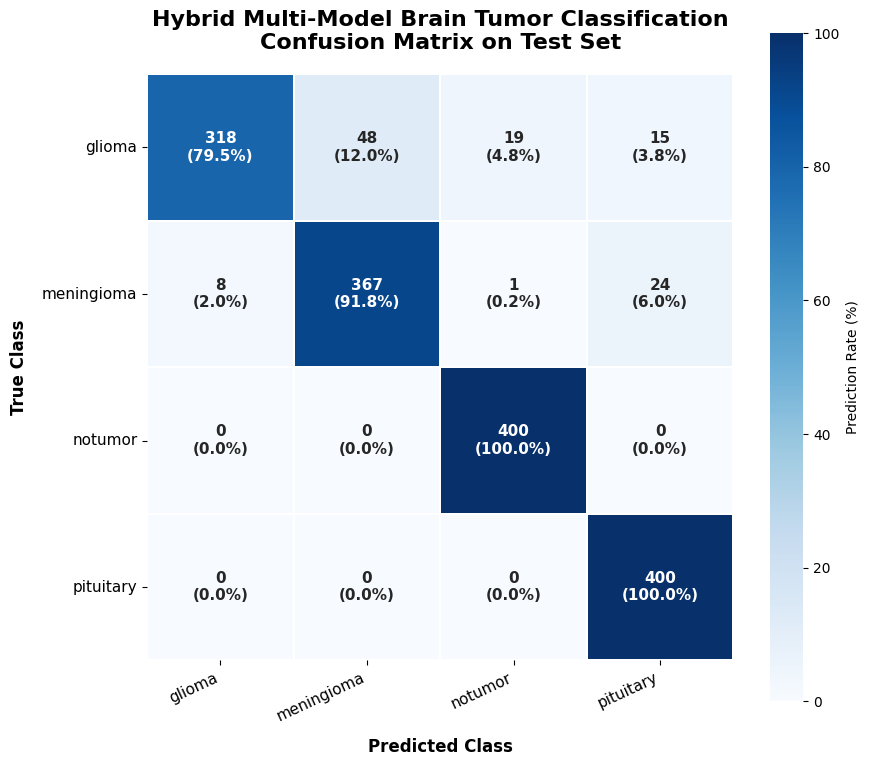

CLASS-WISE CONFUSION MATRIX SUMMARY
glioma          :  318/ 400 correct ( 79.50%)
meningioma      :  367/ 400 correct ( 91.75%)
notumor         :  400/ 400 correct (100.00%)
pituitary       :  400/ 400 correct (100.00%)


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(
    test_label_ids,
    test_pred_ids
)

# Row-wise percentages
cm_percent = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True) * 100

# Combined annotations: Count + Percentage
annotations = np.empty_like(cm, dtype=object)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annotations[i, j] = f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)"

# Figure
plt.figure(figsize=(9, 8))

ax = sns.heatmap(
    cm_percent,
    annot=annotations,
    fmt="",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=1.2,
    linecolor="white",
    square=True,
    cbar_kws={
        "label": "Prediction Rate (%)"
    },
    annot_kws={
        "fontsize": 11,
        "fontweight": "bold"
    }
)

# Titles and labels
plt.title(
    "Hybrid Multi-Model Brain Tumor Classification\n"
    "Confusion Matrix on Test Set",
    fontsize=16,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Predicted Class",
    fontsize=12,
    fontweight="bold",
    labelpad=10
)

plt.ylabel(
    "True Class",
    fontsize=12,
    fontweight="bold",
    labelpad=10
)

plt.xticks(
    rotation=25,
    ha="right",
    fontsize=11
)

plt.yticks(
    rotation=0,
    fontsize=11
)

plt.tight_layout()
plt.show()

print("CLASS-WISE CONFUSION MATRIX SUMMARY")

for i, class_name in enumerate(CLASS_NAMES):

    correct = cm[i, i]
    total = cm[i].sum()
    accuracy = (correct / total) * 100 if total > 0 else 0

    print(
        f"{class_name:15s} : "
        f"{correct:4d}/{total:4d} correct "
        f"({accuracy:6.2f}%)"
    )

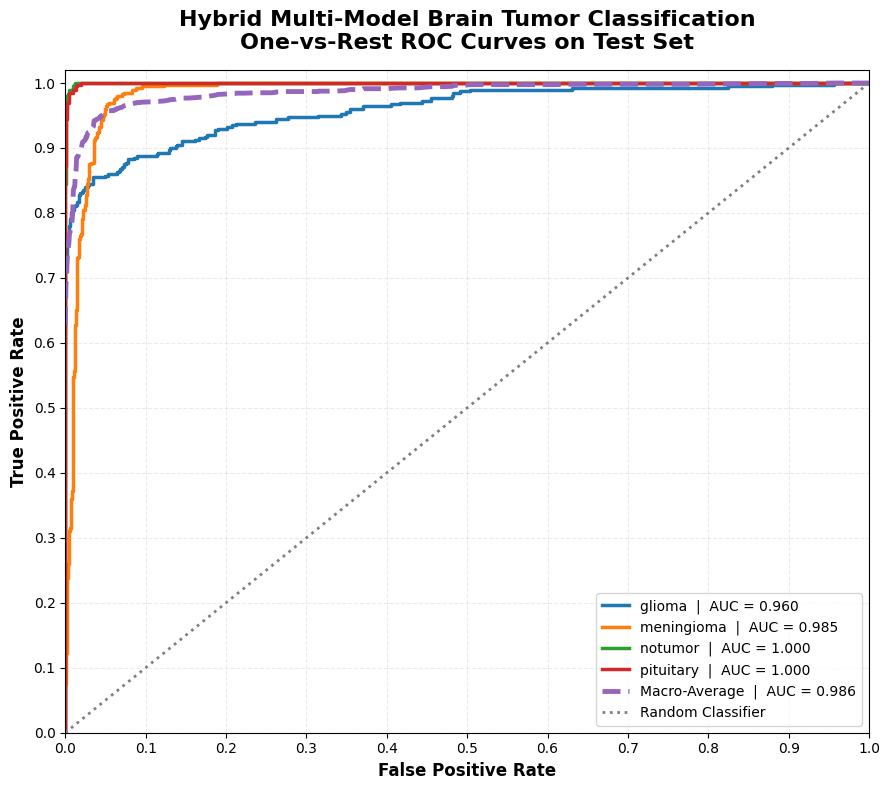

ROC-AUC SUMMARY
glioma          : AUC = 0.9597
meningioma      : AUC = 0.9848
notumor         : AUC = 0.9997
pituitary       : AUC = 0.9996
------------------------------------------------------------
Macro-Average   : AUC = 0.9862


In [24]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

test_bin = label_binarize(
    test_label_ids,
    classes=np.arange(NUM_CLASSES)
)

fpr = {}
tpr = {}
roc_auc = {}

for i, class_name in enumerate(CLASS_NAMES):

    fpr[i], tpr[i], _ = roc_curve(
        test_bin[:, i],
        test_probs[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

all_fpr = np.unique(
    np.concatenate(
        [fpr[i] for i in range(NUM_CLASSES)]
    )
)

mean_tpr = np.zeros_like(all_fpr)

for i in range(NUM_CLASSES):
    mean_tpr += np.interp(
        all_fpr,
        fpr[i],
        tpr[i]
    )

mean_tpr /= NUM_CLASSES

macro_auc = auc(
    all_fpr,
    mean_tpr
)

plt.figure(figsize=(9, 8))

for i, class_name in enumerate(CLASS_NAMES):
    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2.5,
        label=f"{class_name}  |  AUC = {roc_auc[i]:.3f}"
    )

# Macro average
plt.plot(
    all_fpr,
    mean_tpr,
    linewidth=3.5,
    linestyle="--",
    label=f"Macro-Average  |  AUC = {macro_auc:.3f}"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    linewidth=2,
    color="gray",
    label="Random Classifier"
)

plt.title(
    "Hybrid Multi-Model Brain Tumor Classification\n"
    "One-vs-Rest ROC Curves on Test Set",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12,
    fontweight="bold"
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.xticks(
    np.arange(0, 1.1, 0.1)
)

plt.yticks(
    np.arange(0, 1.1, 0.1)
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.25
)

plt.legend(
    loc="lower right",
    fontsize=10,
    frameon=True
)

plt.tight_layout()
plt.show()

print("ROC-AUC SUMMARY")

for i, class_name in enumerate(CLASS_NAMES):
    print(
        f"{class_name:15s} : AUC = {roc_auc[i]:.4f}"
    )

print("-" * 60)
print(
    f"{'Macro-Average':15s} : AUC = {macro_auc:.4f}"
)

## 12. Individual Backbone Baselines

To show what the fusion actually buys us, each backbone is also trained **on its own** as a
lightweight standalone classifier (frozen backbone + small head, quick training). These same
trained models are reused in Section 13 as the base learners of a soft-voting ensemble — an
alternative to the fused model that is far cheaper to train if you don't have a big GPU.

In [27]:
from tensorflow.keras import callbacks

In [30]:
import os
import tensorflow as tf

BASELINE_EPOCHS = 15

# PRETRAINED STANDALONE MODEL
def build_standalone_pretrained(
    name,
    Backbone,
    preprocess_fn,
    num_classes=NUM_CLASSES
):

    inp = layers.Input(
        shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
        name=f"{name}_input"
    )

    # Preprocessing
    x = layers.Lambda(
        lambda z: preprocess_fn(z),
        name=f"{name}_preprocess"
    )(inp)

    # Load ImageNet pretrained backbone
    if name == "efficientnetb3":

        try:
            # First try normal Keras ImageNet weights
            base = Backbone(
                include_top=False,
                weights="imagenet",
                input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
                pooling="avg",
                name=f"{name}_backbone"
            )

        except Exception as e:

            print(
                "\nEfficientNetB3 standard ImageNet download failed."
            )
            print("Using legacy EfficientNetB3 weights instead.")

            # Legacy weight location
            legacy_weight_url = (
                "https://storage.googleapis.com/"
                "keras-applications/efficientnetb3_notop.h5"
            )

            # Local cache path
            legacy_weight_path = os.path.expanduser(
                "~/.keras/models/efficientnetb3_notop.h5"
            )

            # Download only if not already available
            if not os.path.exists(legacy_weight_path):

                legacy_weight_path = tf.keras.utils.get_file(
                    fname="efficientnetb3_notop.h5",
                    origin=legacy_weight_url,
                    cache_subdir="models"
                )

            # Build architecture without automatic weights
            base = Backbone(
                include_top=False,
                weights=None,
                input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
                pooling="avg",
                name=f"{name}_backbone"
            )

            # Load legacy ImageNet weights manually
            base.load_weights(
                legacy_weight_path
            )

    else:

        base = Backbone(
            include_top=False,
            weights="imagenet",
            input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
            pooling="avg",
            name=f"{name}_backbone"
        )

    # Freeze backbone
    base.trainable = False

    # Raw GAP feature
    gap = base(x)

    # Classification head
    x = layers.Dense(
        128,
        activation="relu",
        name=f"{name}_dense"
    )(gap)

    x = layers.Dropout(
        0.30,
        name=f"{name}_dropout"
    )(x)

    out = layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
        name=f"{name}_output"
    )(x)

    model = models.Model(
        inputs=inp,
        outputs=out,
        name=f"{name}_standalone"
    )

    model.compile(
        optimizer=optimizers.Adam(
            learning_rate=1e-4
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# CUSTOM / MEDICALNET STANDALONE MODEL
def build_standalone_custom(
    name,
    feature_fn,
    num_classes=NUM_CLASSES
):

    inp = layers.Input(
        shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
        name=f"{name}_input"
    )

    gap = feature_fn(inp)

    x = layers.Dense(
        128,
        activation="relu",
        name=f"{name}_dense"
    )(gap)

    x = layers.Dropout(
        0.30,
        name=f"{name}_dropout"
    )(x)

    out = layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
        name=f"{name}_output"
    )(x)

    model = models.Model(
        inputs=inp,
        outputs=out,
        name=f"{name}_standalone"
    )

    model.compile(
        optimizer=optimizers.Adam(
            learning_rate=1e-4
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# BASELINE STORAGE
baseline_models = {}
baseline_histories = {}

# FUNCTION TO CREATE A FRESH CALLBACK
# IMPORTANT: NEW CALLBACK FOR EVERY MODEL
def get_baseline_callbacks():

    return [
        callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=3,
            restore_best_weights=True,
            verbose=1
        )
    ]

# PRETRAINED BASELINES
standalone_specs = {

    "vgg16": (
        vgg16.VGG16,
        vgg16.preprocess_input
    ),

    "resnet50": (
        resnet50.ResNet50,
        resnet50.preprocess_input
    ),

    "densenet121": (
        densenet.DenseNet121,
        densenet.preprocess_input
    ),

    "efficientnetb3": (
        efficientnet.EfficientNetB3,
        efficientnet.preprocess_input
    ),
}


for name, (Backbone, preprocess_fn) in standalone_specs.items():

    print(f"Training standalone {name}")
    
    # Build model
    m = build_standalone_pretrained(
        name=name,
        Backbone=Backbone,
        preprocess_fn=preprocess_fn,
        num_classes=NUM_CLASSES
    )

    # Fresh EarlyStopping object for this model
    model_callbacks = get_baseline_callbacks()

    # Train
    h = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=BASELINE_EPOCHS,
        class_weight=class_weights,
        callbacks=model_callbacks,
        verbose=1
    )

    baseline_models[name] = m
    baseline_histories[name] = h

# CUSTOM CNN
def _custom_cnn_feature(inp):

    return build_custom_cnn_branch(
        inp,
        proj_dim=PROJ_DIM
    )


print("Training standalone custom CNN")

m = build_standalone_custom(
    name="customcnn",
    feature_fn=_custom_cnn_feature,
    num_classes=NUM_CLASSES
)

h = m.fit(
    train_ds,
    validation_data=val_ds,
    epochs=BASELINE_EPOCHS,
    class_weight=class_weights,
    callbacks=get_baseline_callbacks(),
    verbose=1
)

baseline_models["customcnn"] = m
baseline_histories["customcnn"] = h

# MEDICALNET-INSPIRED
def _mednet_feature(inp):

    return build_medicalnet_inspired_branch(
        inp,
        proj_dim=PROJ_DIM
    )


print("Training standalone MedicalNet-inspired")

m = build_standalone_custom(
    name="mednet_inspired",
    feature_fn=_mednet_feature,
    num_classes=NUM_CLASSES
)

h = m.fit(
    train_ds,
    validation_data=val_ds,
    epochs=BASELINE_EPOCHS,
    class_weight=class_weights,
    callbacks=get_baseline_callbacks(),
    verbose=1
)

baseline_models["mednet_inspired"] = m
baseline_histories["mednet_inspired"] = h

Training standalone vgg16
Epoch 1/15
298/298 ━━━━━━━━━━━━━━━━━━━━ 57s 181ms/step - accuracy: 0.5074 - loss: 1.9876 - val_accuracy: 0.7286 - val_loss: 0.7225
Epoch 2/15
298/298 ━━━━━━━━━━━━━━━━━━━━ 51s 172ms/step - accuracy: 0.7248 - loss: 0.7894 - val_accuracy: 0.7964 - val_loss: 0.5628
Epoch 3/15
298/298 ━━━━━━━━━━━━━━━━━━━━ 51s 172ms/step - accuracy: 0.7794 - loss: 0.6115 - val_accuracy: 0.8226 - val_loss: 0.4672
Epoch 4/15
298/298 ━━━━━━━━━━━━━━━━━━━━ 83s 174ms/step - accuracy: 0.8055 - loss: 0.5158 - val_accuracy: 0.8452 - val_loss: 0.4292
Epoch 5/15
298/298 ━━━━━━━━━━━━━━━━━━━━ 51s 171ms/step - accuracy: 0.8298 - loss: 0.4588 - val_accuracy: 0.8583 - val_loss: 0.4059
Epoch 6/15
298/298 ━━━━━━━━━━━━━━━━━━━━ 51s 172ms/step - accuracy: 0.8389 - loss: 0.4399 - val_accuracy: 0.8702 - val_loss: 0.3693
Epoch 7/15
298/298 ━━━━━━━━━━━━━━━━━━━━ 51s 172ms/step - accuracy: 0.8590 - loss: 0.3838 - val_accuracy: 0.8750 - val_loss: 0.3467
Epoch 8/15
298/298 ━━━━━━━━━━━━━━━━━━━━ 52s 174ms/step - 

100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step
vgg16              test accuracy: 0.8600
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step
resnet50           test accuracy: 0.8775
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step
densenet121        test accuracy: 0.8344
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step
efficientnetb3     test accuracy: 0.8431
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
customcnn          test accuracy: 0.7944
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
mednet_inspired    test accuracy: 0.7231


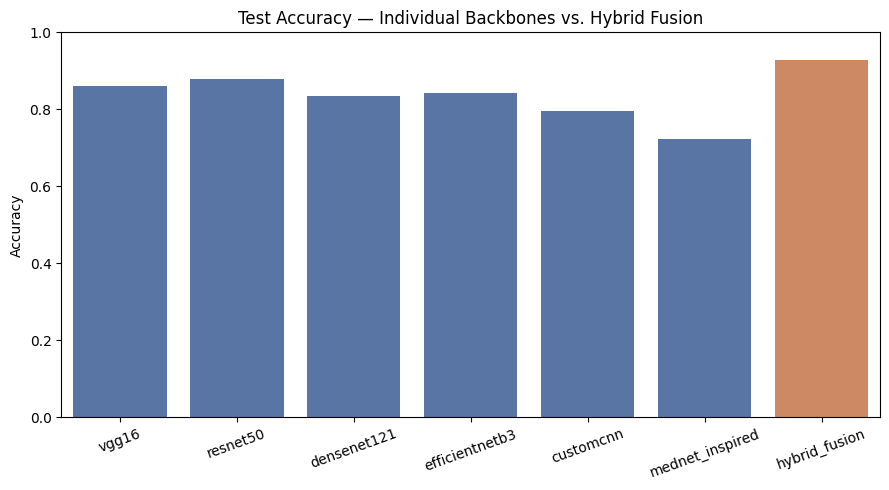

In [31]:
baseline_test_probs = {}
baseline_test_acc = {}

for name, m in baseline_models.items():
    probs = m.predict(test_ds)
    preds = np.argmax(probs, axis=1)
    acc = (preds == test_label_ids).mean()
    baseline_test_probs[name] = probs
    baseline_test_acc[name] = acc
    print(f"{name:18s} test accuracy: {acc:.4f}")

hybrid_test_acc = (test_pred_ids == test_label_ids).mean()
baseline_test_acc['hybrid_fusion'] = hybrid_test_acc

plt.figure(figsize=(9, 5))
names = list(baseline_test_acc.keys())
accs = [baseline_test_acc[n] for n in names]
colors = ['#4C72B0'] * (len(names) - 1) + ['#DD8452']
sns.barplot(x=names, y=accs, hue=names, palette=colors, legend=False)
plt.title('Test Accuracy — Individual Backbones vs. Hybrid Fusion')
plt.ylabel('Accuracy')
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 13. Weighted Soft-Voting Ensemble (Approach B)

If training the full fused model end-to-end isn't feasible on your hardware, this section builds
an ensemble the cheap way: reuse the **already-trained standalone models** from Section 12 and
combine their predicted probabilities with weights proportional to each model's validation
accuracy. No retraining, no giant multi-branch graph in memory at once.

In [32]:
val_label_ids = np.array([CLASS_TO_IDX[l] for l in val_labels])

val_accs = {}
for name, m in baseline_models.items():
    val_probs = m.predict(val_ds)
    val_preds = np.argmax(val_probs, axis=1)
    val_accs[name] = (val_preds == val_label_ids).mean()

# Softmax-normalize validation accuracies into ensemble weights
weight_arr = np.array(list(val_accs.values()))
ensemble_weights = weight_arr / weight_arr.sum()
ensemble_weights = dict(zip(val_accs.keys(), ensemble_weights))
print("Ensemble weights (by validation accuracy):")
for k, v in ensemble_weights.items():
    print(f"  {k:18s} {v:.4f}")

def weighted_soft_vote(probs_dict, weights_dict):
    total = None
    for name, probs in probs_dict.items():
        w = weights_dict[name]
        total = w * probs if total is None else total + w * probs
    return total

ensemble_test_probs = weighted_soft_vote(baseline_test_probs, ensemble_weights)
ensemble_preds = np.argmax(ensemble_test_probs, axis=1)
ensemble_acc = (ensemble_preds == test_label_ids).mean()

print(f"\nWeighted soft-voting ensemble test accuracy: {ensemble_acc:.4f}")
print(f"Hybrid fusion model test accuracy:            {hybrid_test_acc:.4f}")
print("\nEnsemble classification report:")
print(classification_report(test_label_ids, ensemble_preds, target_names=CLASS_NAMES))


53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 262ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 220ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
Ensemble weights (by validation accuracy):
  vgg16              0.1730
  resnet50           0.1782
  densenet121        0.1698
  efficientnetb3     0.1661
  customcnn          0.1645
  mednet_inspired    0.1484

Weighted soft-voting ensemble test accuracy: 0.8800
Hybrid fusion model test accuracy:            0.9281

Ensemble classification report:
              precision    recall  f1-score   support

      glioma       0.97      0.69      0.80       400
  meningioma       0.79      0.85      0.82       400
     notumor       0.89      0.99      0.94       400
   pituitary       0.90      0.99      0.94       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89 

## 14. Grad-CAM Explainability

For a medical-imaging model, showing *which pixels* drove a prediction matters. This uses
Grad-CAM on the DenseNet121 branch inside the hybrid model to highlight the regions that most
influenced the final classification.

Backbone found: densenet121
Last Conv layer: conv5_block16_2_conv


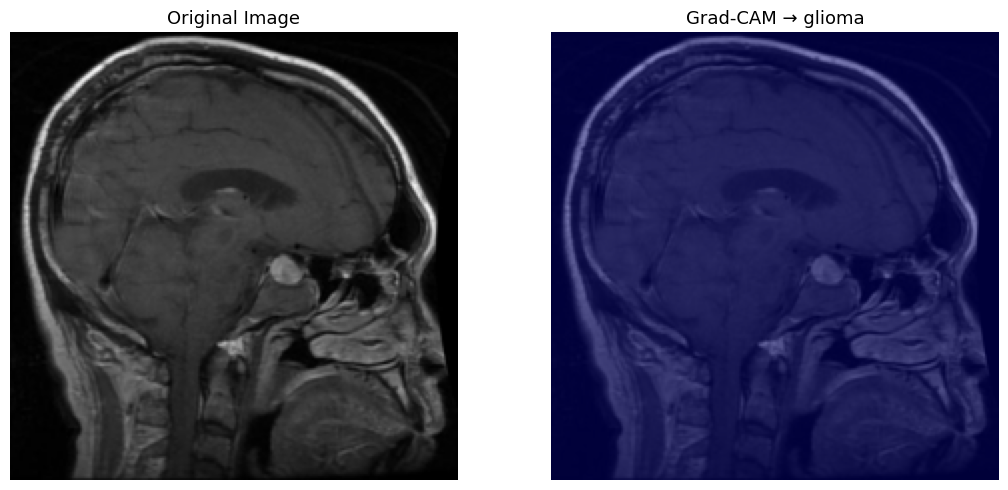

In [38]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

densenet_branch = hybrid_model.get_layer('densenet121_branch')

densenet_backbone = None
for layer in densenet_branch.layers:
    if isinstance(layer, tf.keras.Model) and 'densenet' in layer.name.lower():
        densenet_backbone = layer
        break

if densenet_backbone is None:
    # fallback
    densenet_backbone = densenet_branch.layers[1]  # সাধারণত দ্বিতীয় লেয়ার হয়

print("Backbone found:", densenet_backbone.name)

last_conv_layer = None
for layer in reversed(densenet_backbone.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break

print("Last Conv layer:", last_conv_layer.name)


def make_gradcam_heatmap(img_array, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=densenet_backbone.input,
        outputs=[last_conv_layer.output, densenet_backbone.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        
        if pred_index is None:
            hybrid_pred = hybrid_model(img_array)
            pred_index = tf.argmax(hybrid_pred[0])
        
        class_channel = predictions[:, pred_index] if predictions.shape[-1] > 1 else predictions

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    
    return heatmap.numpy(), int(pred_index)


def show_gradcam(img_path, alpha=0.45):
    img = Image.open(img_path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
    img_array = np.expand_dims(np.array(img).astype(np.float32), axis=0)

    # DenseNet preprocessing  (caffe style)
    img_array_preprocessed = tf.keras.applications.densenet.preprocess_input(img_array.copy())

    heatmap, pred_index = make_gradcam_heatmap(img_array_preprocessed)

    # Create Heatmap
    heatmap_resized = np.array(
        Image.fromarray(np.uint8(255 * heatmap)).resize((IMAGE_SIZE, IMAGE_SIZE))
    )
    heatmap_colored = plt.cm.jet(heatmap_resized / 255.0)[..., :3]

    overlay = (1 - alpha) * (np.array(img) / 255.0) + alpha * heatmap_colored
    overlay = np.clip(overlay, 0, 1)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    
    axes[0].imshow(img)
    axes[0].set_title("Original Image", fontsize=13)
    axes[0].axis('off')

    axes[1].imshow(overlay)
    axes[1].set_title(f"Grad-CAM → {CLASS_NAMES[pred_index]}", fontsize=13)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Example
show_gradcam(test_paths[0])

## 15. Save / Load the Hybrid Model

In [42]:
hybrid_model.save_weights('hybrid_brain_tumor_weights.weights.h5')

hybrid_model.save('hybrid_brain_tumor_model.keras')

In [45]:
hybrid_model, backbones = build_hybrid_model()

hybrid_model.load_weights('hybrid_brain_tumor_weights.weights.h5')

print("Model loaded successfully!")

Model loaded successfully!


## 16. Single-Image Inference Tool

In [47]:
def detect_and_display(img_path, model=hybrid_model, image_size=IMAGE_SIZE, class_names=CLASS_NAMES):
    """Loads an MRI image, runs the hybrid model, and displays the predicted class + confidence."""
    try:
        img = Image.open(img_path).convert('RGB').resize((image_size, image_size))
        img_array = np.expand_dims(np.array(img).astype(np.float32), axis=0)  # kept in [0,255]

        predictions = model.predict(img_array, verbose=0)
        predicted_index = int(np.argmax(predictions, axis=1)[0])
        confidence = float(np.max(predictions, axis=1)[0])

        predicted_class = class_names[predicted_index]
        result = "No Tumor" if predicted_class == 'notumor' else f"Tumor: {predicted_class}"

        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{result}  (confidence: {confidence * 100:.2f}%)")
        plt.show()

        return predicted_class, confidence

    except Exception as e:
        print("Error processing the image:", str(e))
        return None, None


## 17. Batch Inference Demo

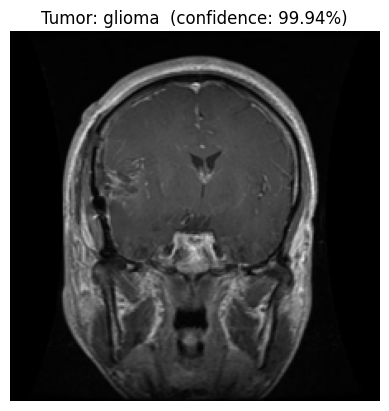

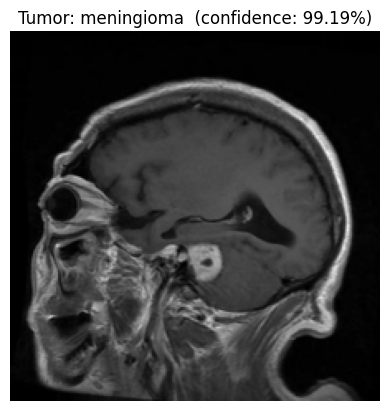

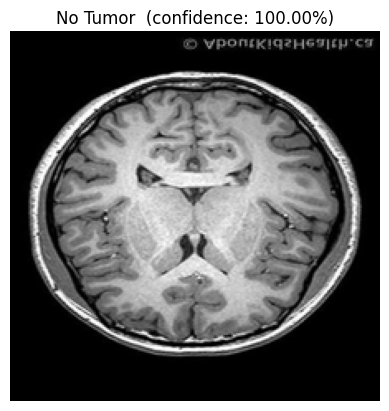

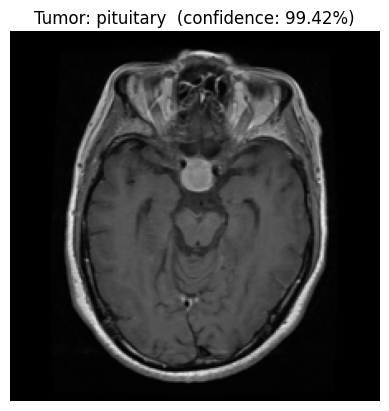

In [50]:
example_images = [
    "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/glioma/Te-gl_112.jpg",
    "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/meningioma/Te-aug-me_101.jpg",
    "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/notumor/Te-no_109.jpg",
    "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/pituitary/Te-pi_119.jpg",
]

for path in example_images:
    if os.path.exists(path):
        detect_and_display(path)
    else:
        print(f"Skipping (not found): {path}")


## 18. Appendix — Plugging In a *True* 3D MedicalNet Branch

If you later have **3D volumetric scans** (NIfTI/DICOM series, not single 2D slices) and want the
real Med3D-pretrained 3D ResNet instead of the 2D residual stand-in used above:

1. Get the official Med3D repository and its PyTorch `.pth` checkpoints (e.g. `resnet_18_23dataset.pth`).
2. Build the 3D ResNet in PyTorch and load those weights; run it as a **separate PyTorch inference service**
   (TensorFlow cannot load PyTorch `.pth` weights directly, and Med3D's architecture is 3D-convolutional).
3. For each volume, extract the Med3D penultimate-layer embedding (a feature vector) with that PyTorch model.
4. Feed those embeddings into this notebook as an **extra precomputed input** — e.g. save them as a NumPy
   array keyed by patient/scan ID, load them alongside the 2D slice paths, and concatenate them with the
   other five branches' projected features before the fusion `Dense` layers (same pattern as
   `build_projection_head`, just applied to a NumPy vector `Input` instead of an image branch).
5. Train the fusion head as in Section 9, now with a genuine 3D-pretrained medical signal included.

This keeps the same hybrid-fusion design used throughout the notebook, and is the technically correct way
to bring real MedicalNet weights into the ensemble once 3D data is available.